# **MODEL DE CALCUL DE RENDEMENT AGRICOLE**


## **A. ANALYSE DESCRIPTIVE ET MODELISATION**

### **1. Importation des bibliothèques**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import os
import seaborn as sns


### **2. Importation du dataset**

In [2]:
data = pd.read_csv('donnees_nettoyees_benin.csv')
data.head()

,produit,annee,communes,superficie,production,rendement,Haut_cumul,NJ_cumul,Haut_moyenne
0,MAIS,2012-2013,ABOMEY,2205.000000,2168.400000,983.401361,997.10,62.0,83.09
1,MAIS,2012-2013,ABOMEY-CALAVI,9916.000000,14314.850000,1443.611335,1186.46,35.0,98.87
2,MAIS,2012-2013,ADJA-OUERE,12461.707252,13904.427053,1115.772243,1100.96,47.0,91.75
3,MAIS,2012-2013,ADJARRA,1324.033150,1520.088189,1148.074117,1308.30,69.0,109.02
4,MAIS,2012-2013,ADJOHOUN,35538.543501,49692.697250,1398.276135,1344.61,66.0,112.05


In [3]:
data.shape

(20721, 9)

### **3. Statistiques descriptives**

In [4]:
data.describe()

c:\Users\Masters\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,superficie,production,rendement,Haut_cumul,NJ_cumul,Haut_moyenne
count,20721.000000,20721.000000,2.072100e+04,20721.000000,20721.000000,20721.000000
mean,2278.656163,7272.788555,inf,1167.686896,64.722797,97.307262
std,8011.509509,32358.282086,NaN,475.195495,24.990239,39.599590
min,0.000000,0.000000,0.000000e+00,196.240000,16.000000,16.350000
25%,6.000000,25.000000,8.415800e+02,901.700000,51.000000,75.140000
50%,98.838001,259.296490,2.522468e+03,1063.800000,58.000000,88.650000
75%,1103.916376,2183.725000,8.226825e+03,1253.970000,69.000000,104.500000
max,487478.753916,971971.966083,inf,4828.200000,187.000000,402.350000


### **3.1 Suppression des NaN**

In [5]:
print(data.isna().sum())

produit         0
annee           0
communes        0
superficie      0
production      0
rendement       0
Haut_cumul      0
NJ_cumul        0
Haut_moyenne    0
dtype: int64


In [6]:
data.dropna(inplace=True)

### **3.2 Suppression des Inf**

In [7]:
print(np.isinf(data['rendement']).sum())

4


In [8]:
import numpy as np

# 1. Remplace inf et -inf par NaN dans tout le DataFrame ou la colonne
data['rendement'] = data['rendement'].replace([np.inf, -np.inf], np.nan)

# 2. Supprime toutes les lignes où 'rendement' est désormais NaN
data = data.dropna(subset=['rendement'])

In [9]:
data.describe()

,superficie,production,rendement,Haut_cumul,NJ_cumul,Haut_moyenne
count,20717.000000,20717.000000,2.071700e+04,20717.000000,20717.000000,20717.000000
mean,2279.096122,7274.192485,1.289320e+04,1167.658189,64.716227,97.304870
std,8012.220356,32361.248161,7.051815e+05,475.182522,24.980160,39.598509
min,0.000000,0.000000,0.000000e+00,196.240000,16.000000,16.350000
25%,6.000000,25.000000,8.415184e+02,901.700000,51.000000,75.140000
50%,98.950000,259.449470,2.520222e+03,1063.800000,58.000000,88.650000
75%,1103.955071,2184.000000,8.226825e+03,1253.970000,69.000000,104.500000
max,487478.753916,971971.966083,7.300901e+07,4828.200000,187.000000,402.350000


In [10]:
data['produit'].value_counts()

produit
TOMATE            996
MAIS              992
MANIOC            991
PIMENT            990
NIEBE             982
ARACHIDE          982
PATATE DOUCE      959
GOMBO             940
RIZ               870
ANACARDE          865
SOJA              739
IGNAME            682
GBOMA             681
CRINCRIN          651
COTON             632
VOANDZOU          589
SORGHO            588
GOUSSI            578
PETIT MIL         536
LAITUE            529
POIDS D'ANGOLE    526
CHOUX             480
CAROTTE           440
ANANAS            425
TARO              414
OIGNON            394
PASTEQUE          365
CONCOMBRE         344
HARICOT VERT      327
SESAME            301
DOHI              291
POMME TERRE       248
CITULUS           235
FONIO             155
Name: count, dtype: int64

### **4. Analyse Exploratoire des Données**

### **4.1. Visualisation des données**

In [11]:
figure = plt.figure(figsize=(10, 10))

<Figure size 1000x1000 with 0 Axes>

In [12]:
data_temps = data.groupby('annee')[['production', 'Haut_cumul']].mean().reset_index()
data_temps

,annee,production,Haut_cumul
0,2012-2013,8380.562752,1193.460217
1,2013-2014,8969.329649,955.245667
2,2014-2015,9420.475952,1143.966769
3,2015-2016,6874.929443,868.893999
4,2016-2017,7029.365852,1022.114798
5,2017-2018,7399.536081,960.557092
6,2018-2019,7611.123878,1109.927040
7,2019-2020,8089.288171,1226.412392
8,2020-2021,8110.790283,992.587756
9,2021-2022,8307.439454,1005.028469


### **4.1.2 Evolution de la production en fonction de la précipittation**

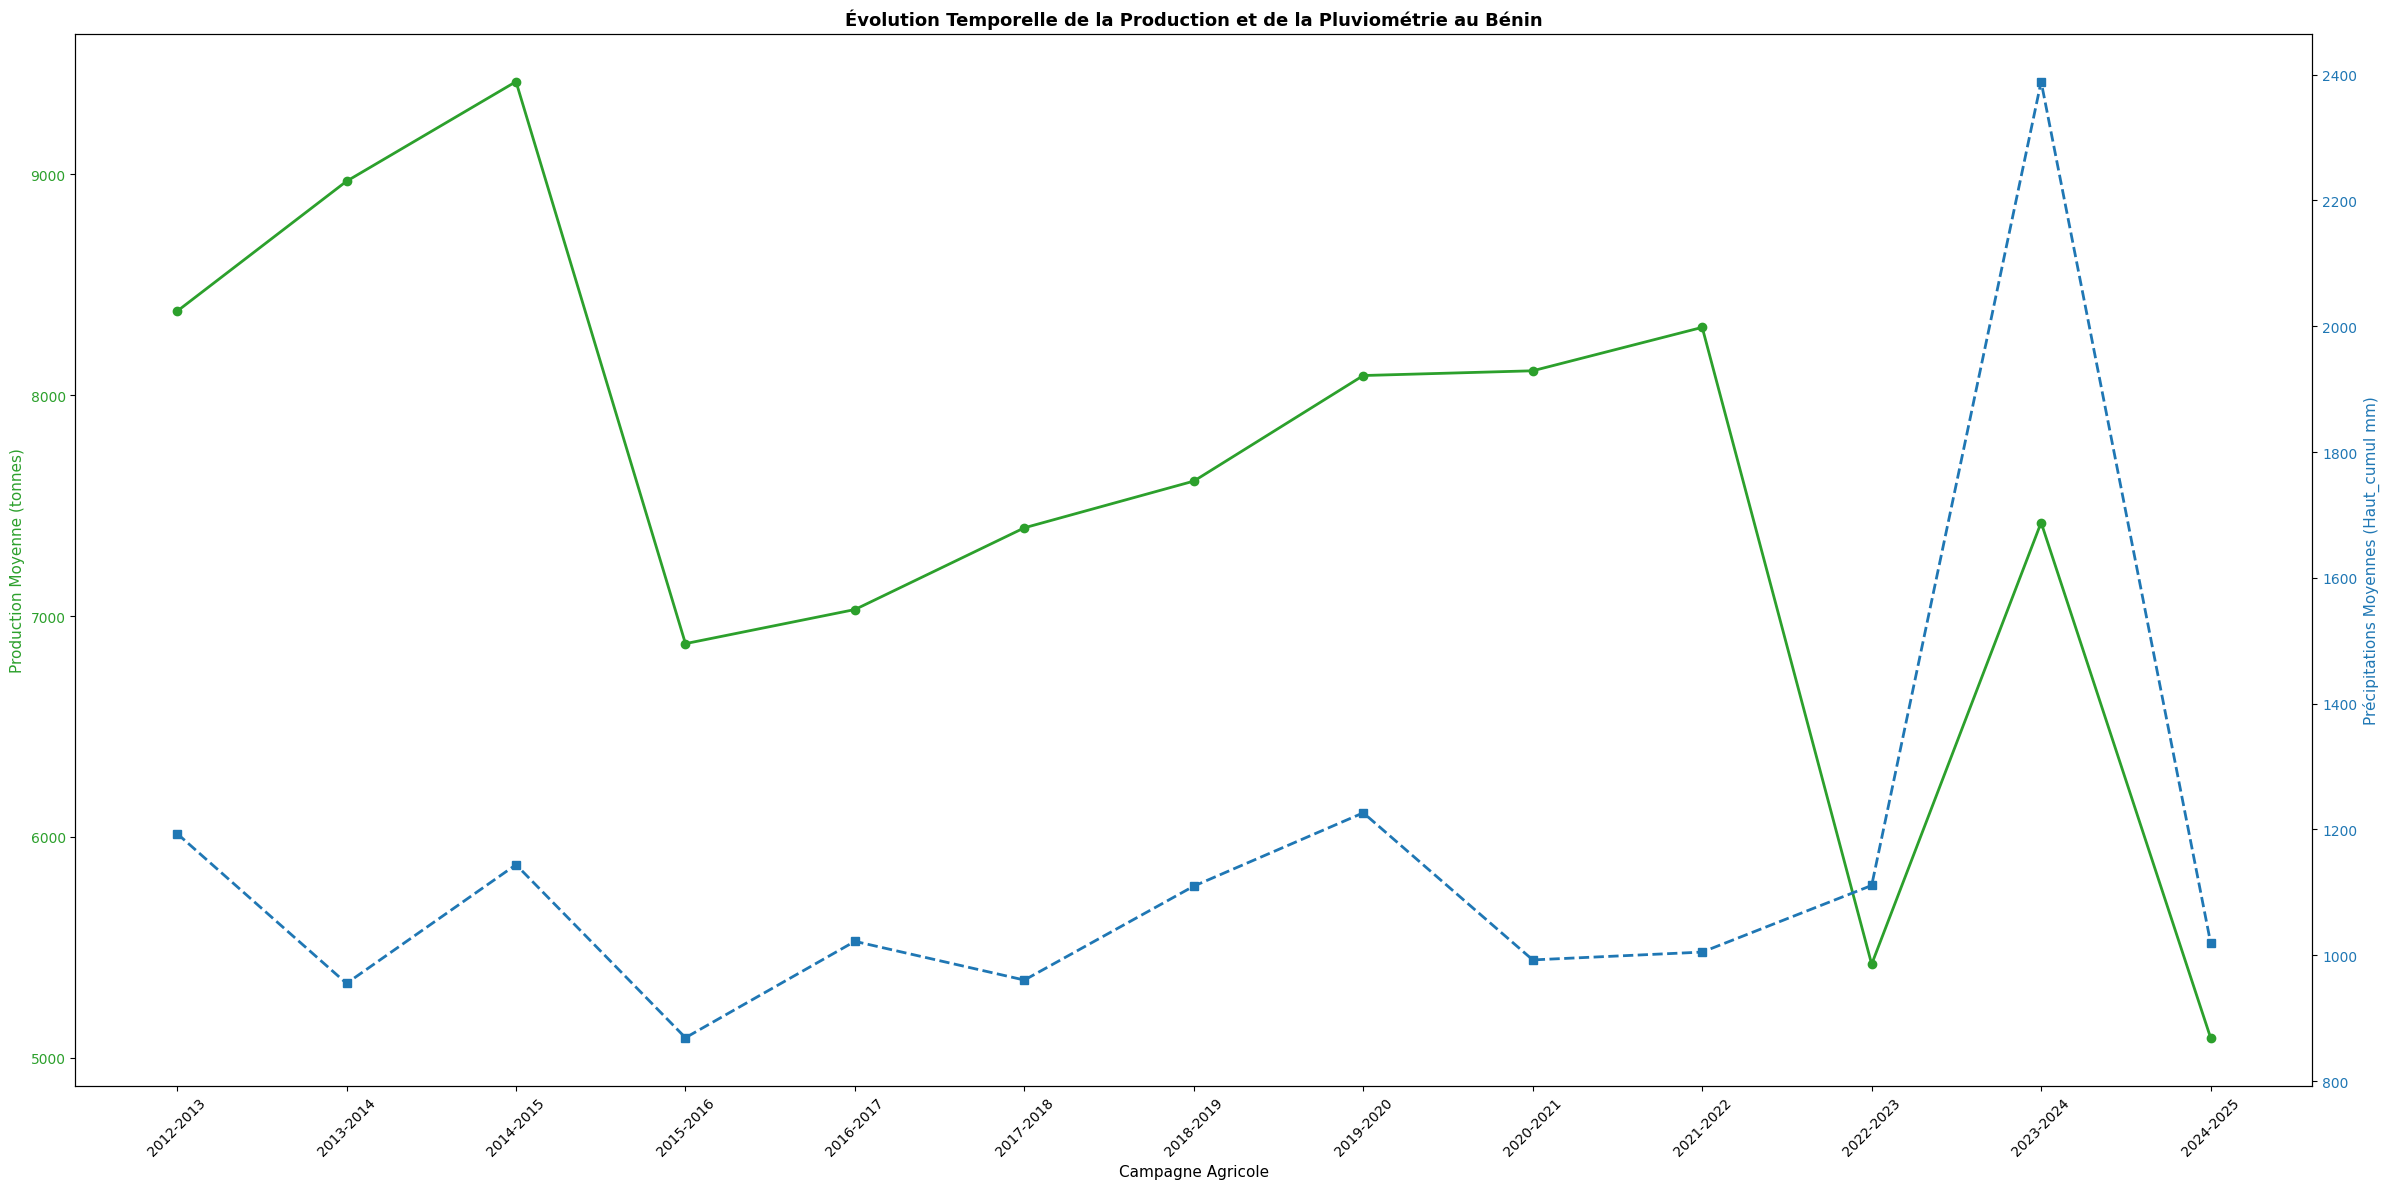

In [13]:

# Groupé par année ou campagne agricole
data_temps = data.groupby('annee')[['production', 'Haut_cumul']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(24, 12))

# Axe 1 : Production
color = 'tab:green'
ax1.set_xlabel('Campagne Agricole', fontsize=11)
ax1.set_ylabel('Production Moyenne (tonnes)', color=color, fontsize=11)
ax1.plot(data_temps['annee'], data_temps['production'], color=color, marker='o', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45)

# Axe 2 : Précipitations
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Précipitations Moyennes (Haut_cumul mm)', color=color, fontsize=11)
ax2.plot(data_temps['annee'], data_temps['Haut_cumul'], color=color, marker='s', linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Évolution Temporelle de la Production et de la Pluviométrie au Bénin', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

### **4.1.3 Matrice de corrélation**

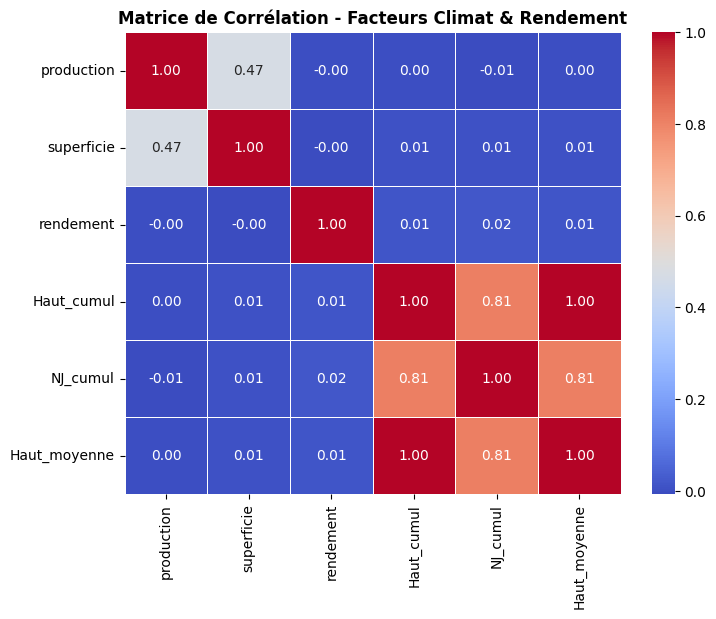

In [14]:

variables_num = ['production','superficie', 'rendement', 'Haut_cumul', 'NJ_cumul', 'Haut_moyenne']

plt.figure(figsize=(8, 6))
sns.heatmap(data[variables_num].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matrice de Corrélation - Facteurs Climat & Rendement', fontsize=12, fontweight='bold')
#plt.tight_layout()
plt.show()

### **4.1.4 Comparaison du rendement moyen des trois cultures phares selon les communes**

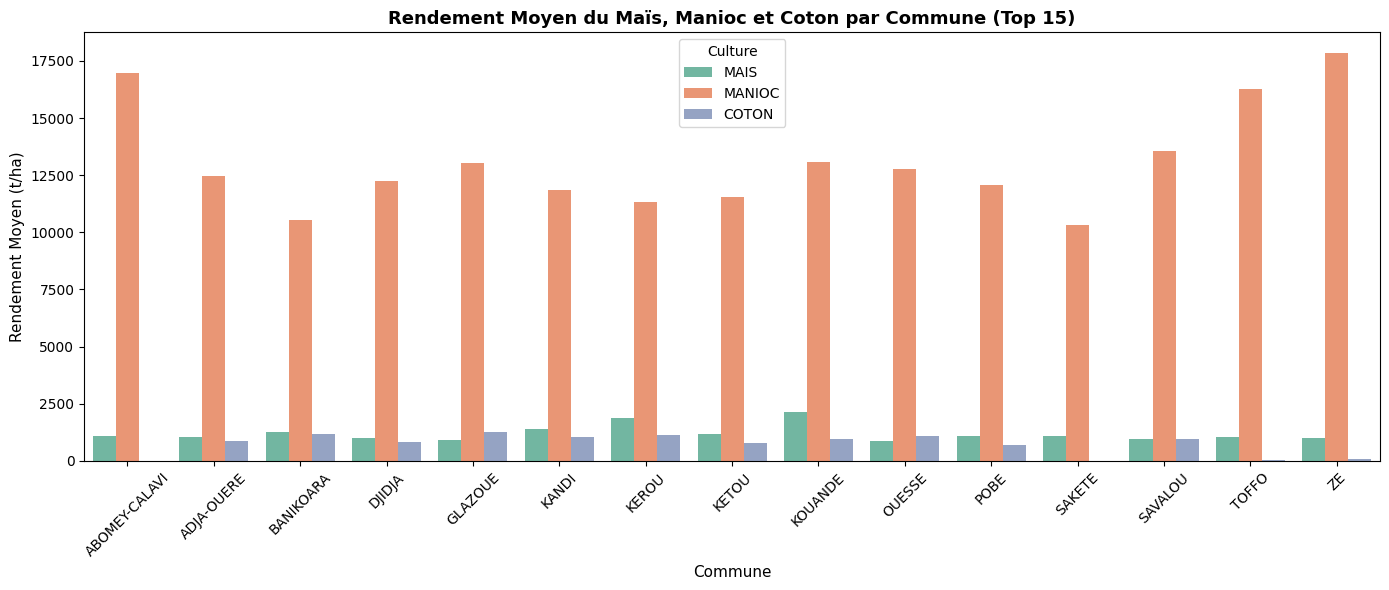

In [15]:
# Filtrer sur les 3 cultures principales
produit_cles = ['MAIS', 'MANIOC', 'COTON']
data_produit = data[data['produit'].str.upper().isin(produit_cles)]

# Sélection des 15 premières communes en termes de volumes
top_communes = data_produit.groupby('communes')['production'].sum().nlargest(15).index
# Fusion des deux jeux de données
data_produit_top_communes = data_produit[data_produit['communes'].isin(top_communes)]

plt.figure(figsize=(14, 6))
sns.barplot(data=data_produit_top_communes, x='communes', y='rendement', hue='produit', errorbar=None, palette='Set2')
plt.title('Rendement Moyen du Maïs, Manioc et Coton par Commune (Top 15)', fontsize=13, fontweight='bold')
plt.xlabel('Commune', fontsize=11)
plt.ylabel('Rendement Moyen (t/ha)', fontsize=11)
plt.xticks(rotation=45)
plt.legend(title='Culture')
plt.tight_layout()
plt.show()

### **4.1.5 Suppression des variables inutiles ou corrélées**

In [16]:
data.drop(columns = ["production","Haut_moyenne"],inplace = True)
data.head(10)

,produit,annee,communes,superficie,rendement,Haut_cumul,NJ_cumul
0,MAIS,2012-2013,ABOMEY,2205.000000,983.401361,997.10,62.0
1,MAIS,2012-2013,ABOMEY-CALAVI,9916.000000,1443.611335,1186.46,35.0
2,MAIS,2012-2013,ADJA-OUERE,12461.707252,1115.772243,1100.96,47.0
3,MAIS,2012-2013,ADJARRA,1324.033150,1148.074117,1308.30,69.0
4,MAIS,2012-2013,ADJOHOUN,35538.543501,1398.276135,1344.61,66.0
5,MAIS,2012-2013,AGBANGNIZOUN,5170.000000,950.684720,1325.00,74.0
6,MAIS,2012-2013,AGUEGUES,1061.500000,3017.200000,1482.00,43.0
7,MAIS,2012-2013,AKPRO-MISSERETE,5479.852791,969.521569,1031.45,58.0
8,MAIS,2012-2013,ALLADA,13983.700000,1329.019501,1127.61,58.0
9,MAIS,2012-2013,APLAHOUE,31084.415109,1044.352000,1353.60,62.0


### **4.5. Préparation des données et features engineering**

### **4.5.1. Importation des librairies**

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


### **4.5.2. Definition des variables explicatives (X) et de la cible (y)**

In [18]:
X = data[['produit', 'communes', 'superficie', 'Haut_cumul', 'NJ_cumul']]

### **4.5.3. Application de la transformation logarithmique pour compresser les écarts de l'echelle**

In [23]:
variables_categorielles = [ 'produit', 'communes',"annee"]# Il faut le mettre dans cet ordre pour que python ne reconnaisse pas les variables_catégorielles
X = data[variables_categorielles + variables_num].copy()
y = np.log1p(data['rendement'])

### **4.5.4. Séparation des données en Train (80%) et Test (20%)**

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)

### **4.5.5 Encodage**

In [25]:
variables_num = ['superficie', 'Haut_cumul', 'NJ_cumul']
variables_categorielles = [ 'produit', 'communes',"annee"]


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), variables_categorielles),
        ('num', 'passthrough', variables_num)
    ]
)

X_train_encode = preprocessor.fit_transform(X_train)
X_test_encode = preprocessor.transform(X_test)

print(f"Dimensions initiales de X_train : {X_train.shape}")
print(f"Dimensions de X_train après encodage : {X_train_encode.shape}")

Dimensions initiales de X_train : (16573, 6)
Dimensions de X_train après encodage : (16573, 127)


# **B. CONSTRUCTION DU MODELE**

### **1. Importation des librairies et initialisation** 

In [26]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
# Initialisation des 3 modèles
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
}

### **2. Optimisation de la Regression Ridge**

In [27]:
# 1. Valeurs à tester pour le paramètre alpha
param_grid_ridge = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

# 2. Configuration de la recherche par validation croisée (5-fold)
grid_ridge = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid_ridge,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# 3. Entraînement et recherche
grid_ridge.fit(X_train_encode, y_train)

# 4. Meilleur modèle Ridge
best_ridge = grid_ridge.best_estimator_

print("--- RIDGE OPTIMISÉ ---")
print(f"Meilleurs paramètres : {grid_ridge.best_params_}")
print(f"Meilleur R² en validation croisée : {grid_ridge.best_score_:.4f}")

--- RIDGE OPTIMISÉ ---
Meilleurs paramètres : {'alpha': 1.0}
Meilleur R² en validation croisée : 0.7203


### **2.1. Visualisation du score en fonction du paramètre**

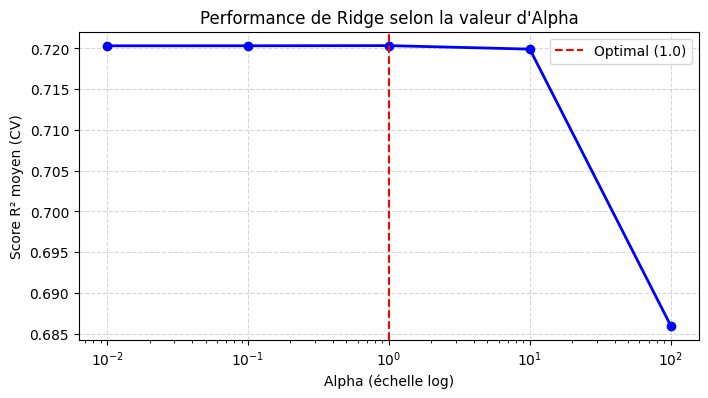

In [28]:

# Extraction des résultats calculés par ton GridSearchCV
alphas = param_grid_ridge['alpha']
scores_moyens = grid_ridge.cv_results_['mean_test_score']

# Tracé du graphique
plt.figure(figsize=(8, 4))
plt.plot(alphas, scores_moyens, marker='o', color='blue', linewidth=2)
plt.xscale('log')
plt.xlabel("Alpha (échelle log)")
plt.ylabel("Score R² moyen (CV)")
plt.title("Performance de Ridge selon la valeur d'Alpha")
plt.axvline(grid_ridge.best_params_['alpha'], color='red', linestyle='--', label=f"Optimal ({grid_ridge.best_params_['alpha']})")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.show()

### **3. Optimisation de Random Forest**

In [29]:
# 1. Grille d'hyperparamètres pour Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

# 2. Configuration du GridSearchCV
grid_random_forest = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# 3. Entraînement et recherche
grid_random_forest.fit(X_train_encode, y_train)

# 4. Extraction du meilleur modèle
meilleur_modele = grid_random_forest.best_estimator_

print("--- RANDOM FOREST OPTIMISÉ ---")
print(f"Meilleurs paramètres : {grid_random_forest.best_params_}")
print(f"Meilleur R² en validation croisée : {grid_random_forest.best_score_:.4f}")

--- RANDOM FOREST OPTIMISÉ ---
Meilleurs paramètres : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur R² en validation croisée : 0.8949


### **3.1. Graphique**

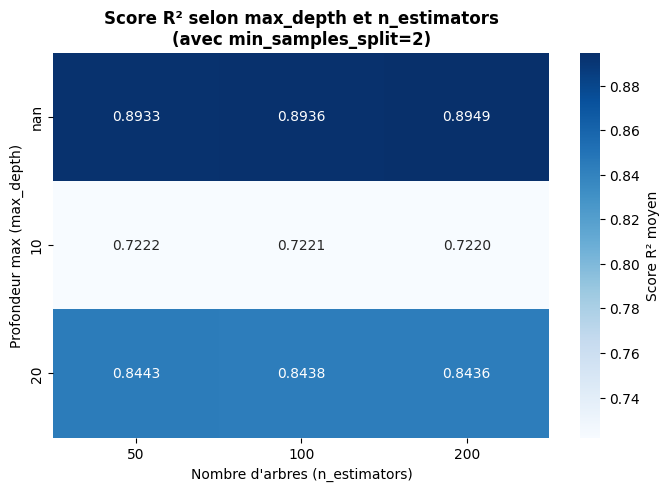

In [30]:
# 1. Conversion des résultats de la grille en DataFrame
results_random_forest = pd.DataFrame(grid_random_forest.cv_results_)

# 2. Création d'une table pivot pour la Heatmap (max_depth vs n_estimators)
# On fixe min_samples_split à sa meilleure valeur pour y voir clair
best_min_samples = grid_random_forest.best_params_['min_samples_split']
resultats_filtre = results_random_forest[results_random_forest['param_min_samples_split'] == best_min_samples]

pivot_table = resultats_filtre.pivot(
    index='param_max_depth', 
    columns='param_n_estimators', 
    values='mean_test_score'
)

# 3. Tracé de la Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap="Blues", cbar_kws={'label': 'Score R² moyen'})

plt.title(f"Score R² selon max_depth et n_estimators\n(avec min_samples_split={best_min_samples})", fontweight='bold')
plt.xlabel("Nombre d'arbres (n_estimators)")
plt.ylabel("Profondeur max (max_depth)")
plt.show()

### **4. Optimisation du modèle de XGBoost**

In [31]:

# 1. Grille d'hyperparamètres pour XGBoost
param_grid_xgboost = {
    'n_estimators': [50, 100],
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1]
}

# 2. Configuration du GridSearchCV
grid_xgboost = GridSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_xgboost,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# 3. Entraînement et recherche
grid_xgboost.fit(X_train_encode, y_train)

# 4. Extraction du meilleur modèle
meilleure_xgboost = grid_xgboost.best_estimator_

print("--- XGBOOST OPTIMISÉ ---")
print(f"Meilleurs paramètres : {grid_xgboost.best_params_}")
print(f"Meilleur R² en validation croisée : {grid_xgboost.best_score_:.4f}")

--- XGBOOST OPTIMISÉ ---
Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}
Meilleur R² en validation croisée : 0.8686


### **5. Tableau et graphique de synthèse finale**

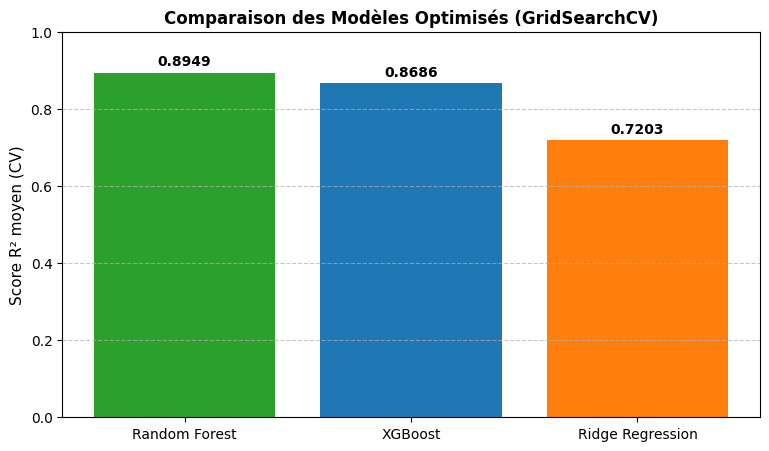

,Modèle,Meilleur R² (CV),Meilleurs Hyperparamètres
0,Random Forest,0.894857,"{'max_depth': None, 'min_samples_split': 2, 'n..."
1,XGBoost,0.868615,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti..."
2,Ridge Regression,0.720350,{'alpha': 1.0}


In [33]:

# 1. Compilation des meilleurs résultats R2
resultats_modeles = {
    "Modèle": ["Random Forest", "XGBoost", "Ridge Regression"],
    "Meilleur R² (CV)": [grid_random_forest.best_score_, grid_xgboost.best_score_, grid_ridge.best_score_],
    "Meilleurs Hyperparamètres": [
        str(grid_random_forest.best_params_),
        str(grid_xgboost.best_params_),
        str(grid_ridge.best_params_)
    ]
}

data_resultats_modele = pd.DataFrame(resultats_modeles)

# 2. Graphique comparatif en barres
plt.figure(figsize=(9, 5))
bars = plt.bar(data_resultats_modele["Modèle"], data_resultats_modele["Meilleur R² (CV)"], color=['#2ca02c', '#1f77b4', '#ff7f0e'])

# Ajout des valeurs au-dessus de chaque barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.0)
plt.ylabel("Score R² moyen (CV)", fontsize=11)
plt.title("Comparaison des Modèles Optimisés (GridSearchCV)", fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Affichage du tableau
data_resultats_modele

### **6. Evaluation du modele RandomForest sur le Jeu de Test**

In [36]:
# 1. Prédictions sur le jeu de test (échelle log)
y_pred_log_random_forest = meilleur_modele.predict(X_test_encode)

# 2. Reconversion en échelle réelle (kg/ha)
y_pred_reel_random_forest = np.expm1(y_pred_log_random_forest)
y_test_reel = np.expm1(y_test)

# 3. Calcul des métriques finales
rmse_random_forest = np.sqrt(mean_squared_error(y_test_reel, y_pred_reel_random_forest))
r2_test_random_forest = r2_score(y_test, y_pred_log_random_forest)

print("--- ÉVALUATION FINALE SUR TEST (RANDOM FOREST) ---")
print(f"R² sur jeu de test : {r2_test_random_forest:.4f}")
print(f"RMSE réel : {rmse_random_forest:.2f} kg/ha")

--- ÉVALUATION FINALE SUR TEST (RANDOM FOREST) ---
R² sur jeu de test : 0.9202
RMSE réel : 2904.69 kg/ha


### **7. Visulisation des valeurs predictes par rapport aux valeurs réelles**

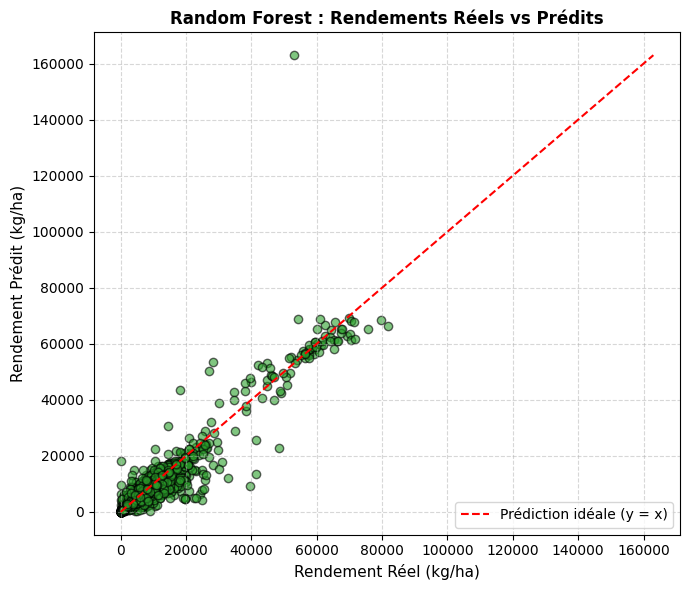

In [37]:
# Tracé des valeurs réelles vs prédites
plt.figure(figsize=(7, 6))
plt.scatter(y_test_reel, y_pred_reel_random_forest, alpha=0.6, color='#2ca02c', edgecolors='k')

# Ligne de référence y = x (prédiction idéale)
max_val = max(max(y_test_reel), max(y_pred_reel_random_forest))
min_val = min(min(y_test_reel), min(y_pred_reel_random_forest))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Prédiction idéale (y = x)')

plt.xlabel("Rendement Réel (kg/ha)", fontsize=11)
plt.ylabel("Rendement Prédit (kg/ha)", fontsize=11)
plt.title("Random Forest : Rendements Réels vs Prédits", fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# **C. SAUVEGARDE ET DEPLOIEMENT DU MODEL**

## **1. Sauvegarde du modele**

In [38]:
import joblib

# Création d'un dictionnaire contenant le préprocesseur et le meilleur modèle
pipeline_complet = {
    'preprocessor': preprocessor,
    'model': meilleur_modele
}

# Sauvegarde dans un fichier
joblib.dump(pipeline_complet, 'modele_rendement_random_forest.joblib')

print("Modèle enregistré avec succès sous le nom 'modele_rendement_random_forest.joblib' !")

Modèle enregistré avec succès sous le nom 'modele_rendement_random_forest.joblib' !


### **1.2. Fonction de prediction pour de nouvelles données**

In [47]:
# Dictionnaire des valeurs météo par défaut par commune
stats_meteo = data.groupby('communes').agg(
    haut_non_favorable=('Haut_cumul', lambda x: x.quantile(0.25)),
    haut_moyen=('Haut_cumul', 'mean'),
    haut_favorable=('Haut_cumul', lambda x: x.quantile(0.75)),
    nj_non_favorable=('NJ_cumul', lambda x: x.quantile(0.25)),
    nj_moyen=('NJ_cumul', 'mean'),
    nj_favorable=('NJ_cumul', lambda x: x.quantile(0.75))
).to_dict(orient='index')

In [48]:
def predire_rendement_flexible(commune, superficie, produit, annee, haut_cumul=None, nj_cumul=None):
    nom_commune = str(commune).strip().upper()

    # CAS 1 : L'utilisateur entre ses propres données météo -> 1 prédiction
    if haut_cumul is not None and nj_cumul is not None:
        donnees = pd.DataFrame([{
            'communes': nom_commune,
            'superficie': superficie,
            'Haut_cumul': haut_cumul,
            'NJ_cumul': nj_cumul,
            'produit': produit,
            'annee': annee
        }])
        donnees_traitees = prep.transform(donnees)
        pred_log = model.predict(donnees_traitees)
        return round(np.expm1(pred_log)[0], 2)

    # CAS 2 : Pas de météo saisie -> 3 prédictions par scénario
    else:
        m = stats_meteo[nom_commune]
        scenarios = {
            'non_favorable': (m['haut_non_favorable'], m['nj_non_favorable']),
            'moyen': (m['haut_moyen'], m['nj_moyen']),
            'favorable': (m['haut_favorable'], m['nj_favorable'])
        }
        
        resultats = {}
        for nom_scenario, (h_val, nj_val) in scenarios.items():
            donnees = pd.DataFrame([{
                'communes': nom_commune,
                'superficie': superficie,
                'Haut_cumul': h_val,
                'NJ_cumul': nj_val,
                'produit': produit,
                'annee': annee
            }])
            donnees_traitees = prep.transform(donnees)
            pred_log = model.predict(donnees_traitees)
            resultats[nom_scenario] = round(np.expm1(pred_log)[0], 2)
            
        return resultats

In [51]:
# TEST 1 : Sans météo (Renvoie les 3 scénarios)
test_scenarios = predire_rendement_flexible(
    commune='BANIKOARA', 
    superficie=2.5, 
    produit='Maïs', 
    annee='2026'
)
print("Scénarios :", test_scenarios)

# TEST 2 : Avec météo exacte (Renvoie 1 valeur directe)
test_direct = predire_rendement_flexible(
    commune='BANIKOARA', 
    superficie=2.5, 
    produit='Maïs', 
    annee='2026', 
    haut_cumul=900.0, 
    nj_cumul=80
)
print("Valeur directe :", test_direct)

Scénarios : {'non_favorable': np.float64(8297.88), 'moyen': np.float64(7982.68), 'favorable': np.float64(6685.19)}
Valeur directe : 7814.66


In [59]:
import joblib

# Si votre préprocesseur et votre modèle sont séparés :
joblib.dump(prep, 'preprocessor.joblib',compress=9)
joblib.dump(model, 'model.joblib',compress=9)

# Si vous aviez combiné les deux dans un seul Pipeline scikit-learn :
# joblib.dump(pipeline_global, 'pipeline_rendement.joblib')

['model.joblib']